First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  


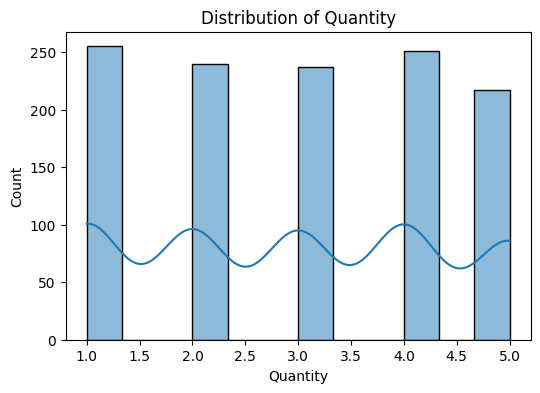

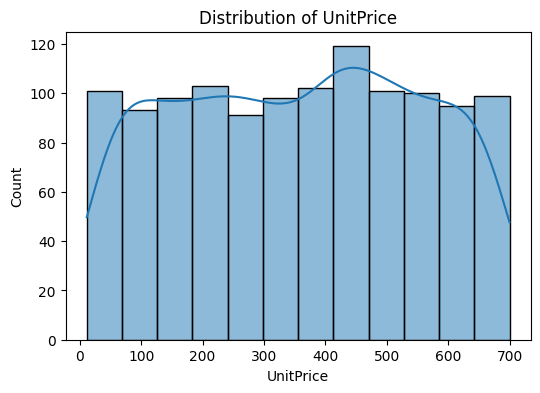

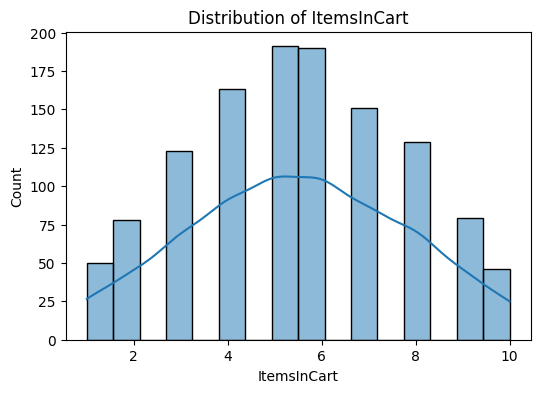

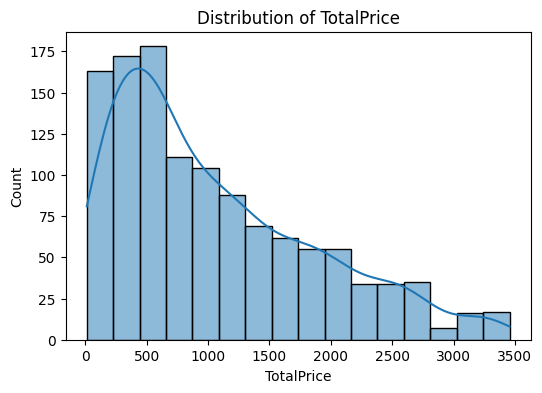

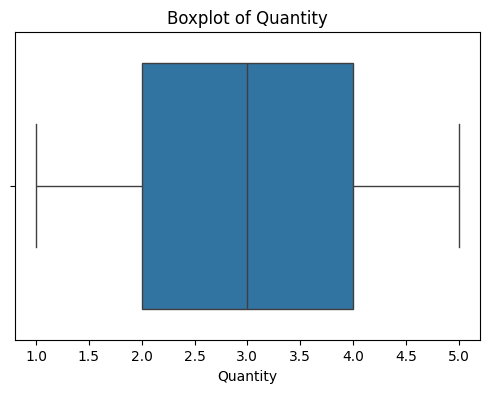

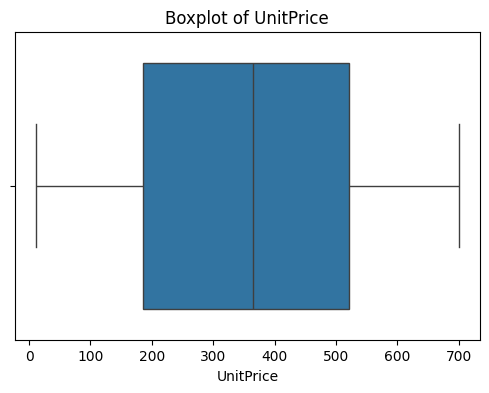

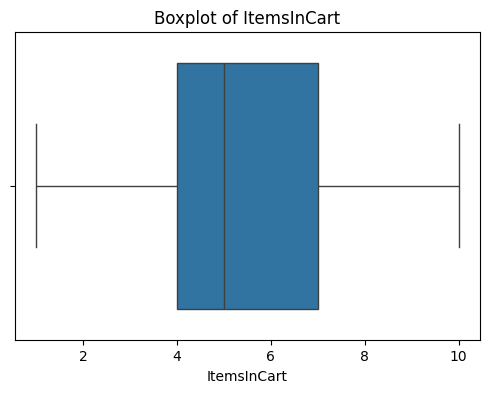

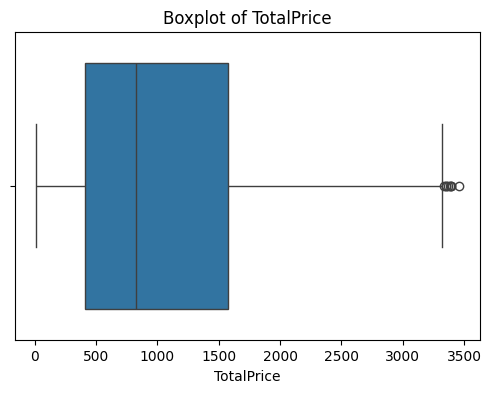


Outlier Detection using IQR
Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


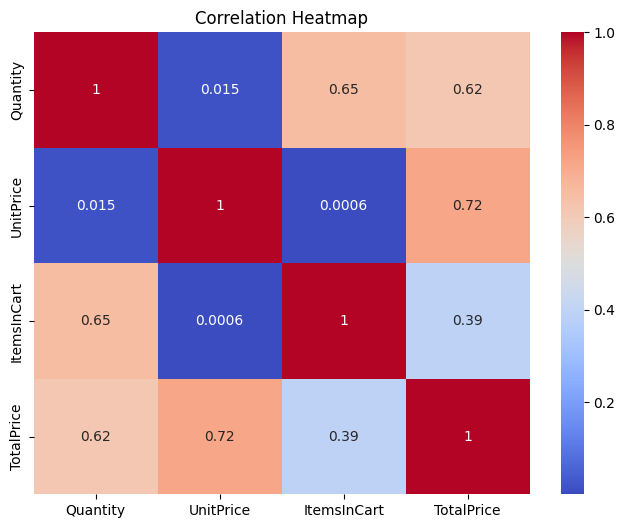

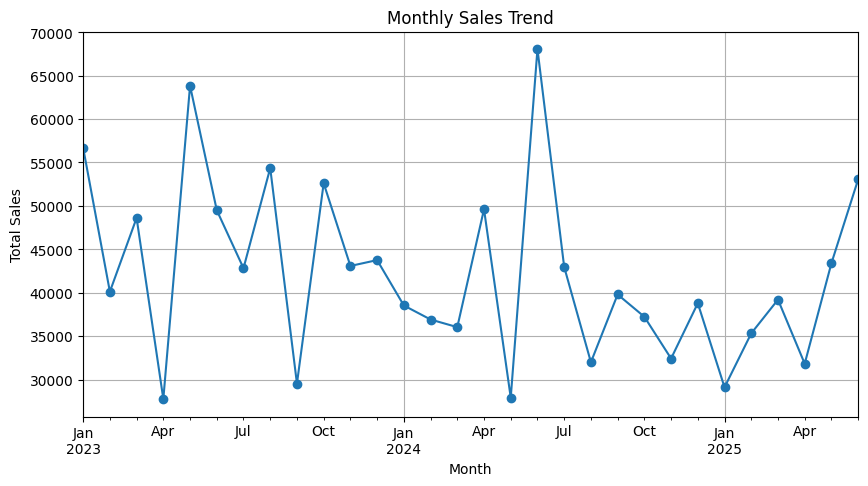

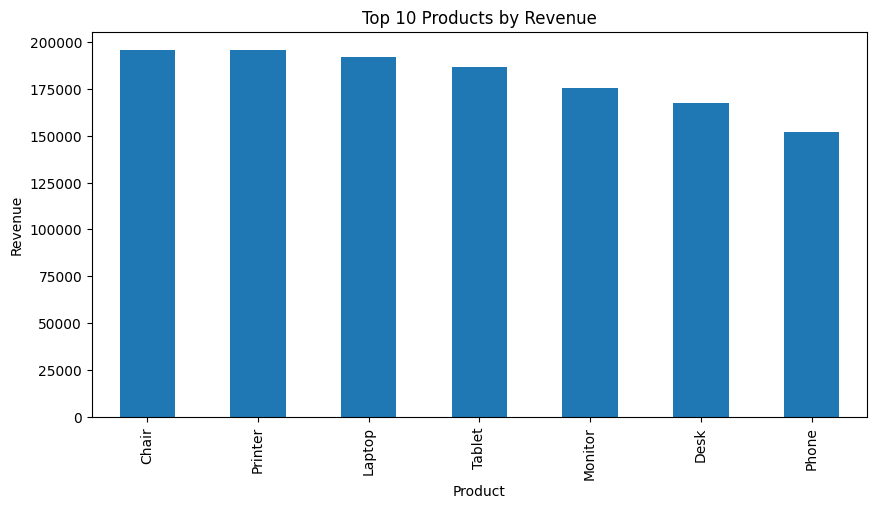


Orders by Payment Method:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Order Status Distribution:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Referral Source Distribution:
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

===== KEY OBSERVATIONS =====
1. Dataset contains 1200 records.
2. Average Order Value: 1053.97
3. Median Order Value: 823.62
4. Highest Order Value: 3456.4
5. Lowest Order Value: 11.39
6. Most Common Payment Method: Online
7. Most Common Order Status: Cancelled
8. Most Effective Referral Source: Instagram

EDA Completed Successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "Dataset for Data Analytics (2).xlsx"
df = pd.read_excel(file_path)

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDescriptive Statistics:")
print(df.describe())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\nColumn: {col}")
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Count :", df[col].count())

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

print("\nOutlier Detection using IQR")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

print("\nOrders by Payment Method:")
print(df['PaymentMethod'].value_counts())

print("\nOrder Status Distribution:")
print(df['OrderStatus'].value_counts())

print("\nReferral Source Distribution:")
print(df['ReferralSource'].value_counts())

print("\n===== KEY OBSERVATIONS =====")
print("1. Dataset contains", len(df), "records.")
print("2. Average Order Value:", round(df['TotalPrice'].mean(), 2))
print("3. Median Order Value:", round(df['TotalPrice'].median(), 2))
print("4. Highest Order Value:", round(df['TotalPrice'].max(), 2))
print("5. Lowest Order Value:", round(df['TotalPrice'].min(), 2))
print("6. Most Common Payment Method:",
      df['PaymentMethod'].mode()[0])
print("7. Most Common Order Status:",
      df['OrderStatus'].mode()[0])
print("8. Most Effective Referral Source:",
      df['ReferralSource'].mode()[0])

print("\nEDA Completed Successfully!")